# Practica 6 - Data cloustering
### Crear un modelo de clasificacion usando el algoritmo K-means

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import math

data = pd.read_csv("../datasets/vgsales_clean.csv")
data.sort_values(by="Ventas_Norteamérica", ascending=True).head()
data.head()

,Nombre,Plataforma,Año,Género,Publicador,Ventas_Norteamérica,Ventas_Europa,Ventas_Japón,Ventas_Otros,Ventas_Globales
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


Con La siguiente grafica podemos ver como es que se relacionan las columnas de Ventas Norteamericanas con las Europeas.<br>
Podemos observar que hay una gran cantidad de juegos que cuentan con bajas ventas tanto en America como en Europa, veremos si K-means logra separarlos. 

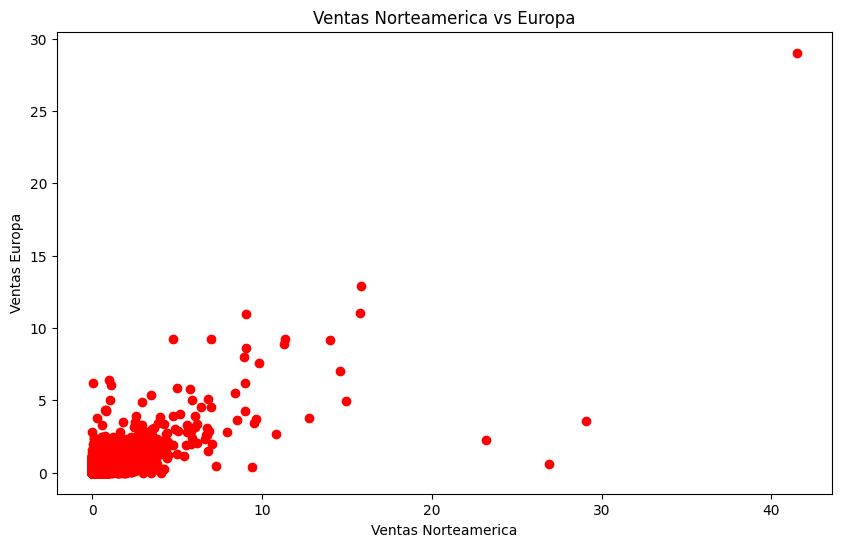

In [32]:
plt.figure(figsize=(10,6))
plt.xlabel('Ventas Norteamerica')
plt.ylabel('Ventas Europa')
plt.title("Ventas Norteamerica vs Europa")
plt.scatter(data['Ventas_Norteamérica'], data['Ventas_Europa'], c='red')
plt.show()

En la siguiente parte de codigo realizamos el algoritmo de K-means junto con todas la funciones que la ocupan, como la distancia euclidiana, el calculo del centroido y la lista de puntos. 

iteracion: 1
iteracion: 2
iteracion: 3
iteracion: 4
iteracion: 5
iteracion: 6
iteracion: 7
iteracion: 8
iteracion: 9
iteracion: 10
iteracion: 11
iteracion: 12
iteracion: 13
iteracion: 14
iteracion: 15
iteracion: 16
iteracion: 17
iteracion: 18
iteracion: 19
iteracion: 20

Final Centroids:
  Cluster 1: [np.float64(0.23960573157709045), np.float64(0.1341936632253367)]
  Cluster 2: [np.float64(9.51122807017544), np.float64(5.023859649122806)]


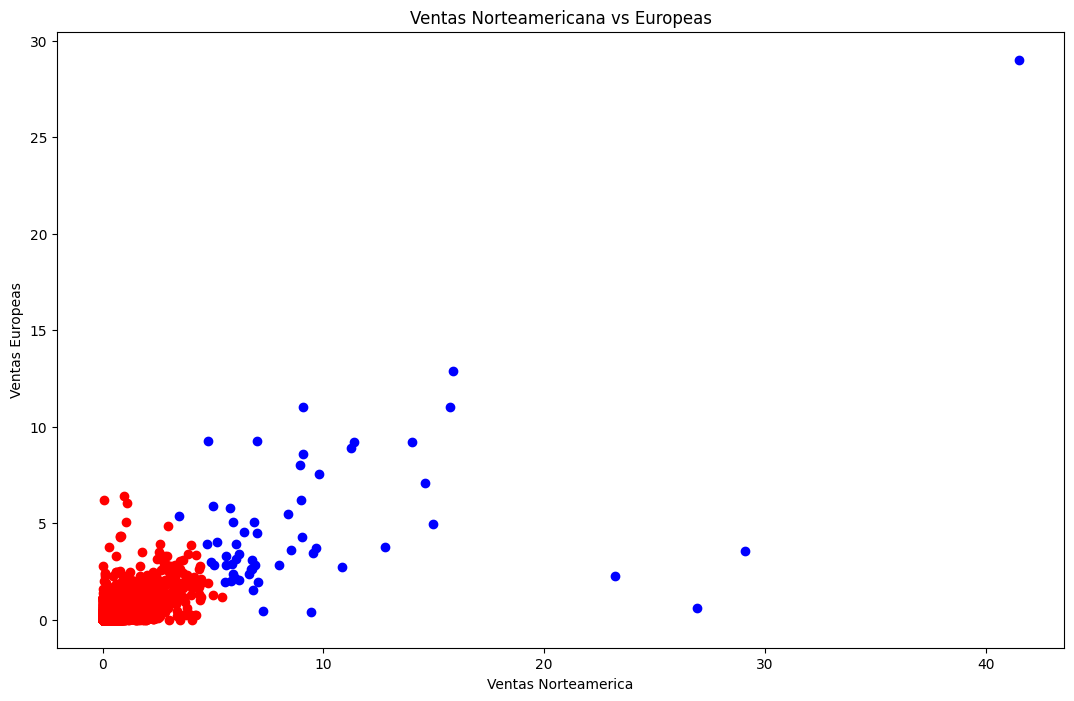

In [31]:
def distancia_euclidiana(punto1, punto2):
    """Retorna la distancia entre dos puntos (x,y) dados"""
    distance = 0
    for i in range(len(punto1)):
        distance += (punto2[i] - punto1[i])**2
    return math.sqrt(distance)

def listaPuntos(x,y):
    """retorna una lista de puntos (x,y)"""
    puntos = [[x[i],y[i]] for i in range(len(x))]
    return puntos

def calcular_centroide(puntos):
    """Calcula el centroide para un conjunto de puntos"""
    if not puntos:
        return []
    centroid = [0] * len(puntos[0])
    
    # Sumamos todas las coordenadas de los puntos
    for punto in puntos:
        for i in range(len(punto)):
            centroid[i] += punto[i]
            
    # formamos las nuevas coordenadas encontrando del promedio (suma de las coordenadas entre el numero de puntos)
    coordenada = [coor/len(puntos) for coor in centroid]
    return coordenada

def kmeans(data, k, iteraciones=100):
    """
    Realiza el algoritmo K-means para una lista de datos (x,y)
    
    Args:
        data: Lista de datos (x,y).
        k: numero de conjuntos.
        iteraciones (int): numero maximo de iteraciones.
        
    Returns:
        el centroide final y la lista de conjuntos.
    """
    # 1. Se inicializa el centroide de forma aleatoria
    centroids = random.sample(data, k)
    
    for i in range(iteraciones):
        # 2. Asignamos puntos para los centroides
        clusters = [[] for _ in range(k)] 
        
        for punto in data:
            distancias = [distancia_euclidiana(punto, centroid) for centroid in centroids]
            index_centroide_cercano = distancias.index(min(distancias))
            clusters[index_centroide_cercano].append(punto)
        
        # Almacenamos centroides antiguos para checar convergencia
        centroids_viejos = centroids
        
        # 3. Calculamos nuevos centroides
        centroids = [calcular_centroide(cluster) for cluster in clusters]
        
        # 4. revisar convergencia
        Converge = True
        for j in range(k):
            # usamos un numero pequeno para la tolerancia
            if distancia_euclidiana(centroids_viejos[j], centroids[j]) > 0.0001:
                print(f"iteracion: {i+1}")
                converge = False
                break
        
        if converge:
            print(f"numero total de iteraciones: {i+1}")
            break
            
    return centroids, clusters

 
# Number of clusters
K = 2

puntos = listaPuntos(data['Ventas_Norteamérica'], data['Ventas_Europa'])

random.seed(42)
    
final_centroids, final_clusters = kmeans(puntos, K)
    
print("\nFinal Centroids:")
for i, centroid in enumerate(final_centroids):
     print(f"  Cluster {i+1}: {centroid}")
      

plt.figure(figsize=(13,8))
plt.xlabel('Ventas Norteamerica')
plt.ylabel('Ventas Europeas')
plt.title("Ventas Norteamericana vs Europeas")
for i, cluster in enumerate(final_clusters):
    for punto in cluster:
        if i == 0:
            plt.scatter(punto[0], punto[1], c='red')
        else:
           plt.scatter(punto[0], punto[1], c='blue')
plt.show()

Como podemos apreciar en la grafica, K-means logro separar los datos en dos conjuntos, los que estan arriba del todo (azules) que podrian representar aquellos juegos que vendieron tanto en europa como en america y los rojos, que podrian representar aquellos juegos que no vendieron en ninguna de las 2 regiones. 